# Prediksi Cuaca Kabupaten Lamongan

Nama Kelompok:
- Tuhu Pangestu
- Intan Aulia Majid
- Farah Dita Artika Febrianti Sriyono
- Muhammad Umar Faruq

### Import Library

In [1]:
import matplotlib.pyplot as plt
import pandas as pd


### Load Dataset

In [2]:
df = pd.read_csv("cuaca_lamongan_harian.csv")

df.head()

,tanggal,kode_cuaca,cuaca,suhu_maks (°C),suhu_min (°C),suhu_rata (°C),kelembapan_rata (%),curah_hujan (mm),durasi_hujan (jam),kecepatan_angin_maks (km/jam),hembusan_angin_maks (km/jam),radiasi_matahari (MJ/m²)
0,2010-01-01,63,Hujan Sedang,29.569500,24.869501,26.621584,86.880270,8.099999,13.0,10.948973,22.319998,18.00
1,2010-01-02,53,Gerimis Sedang,30.469501,25.069500,27.263250,85.656075,1.500000,4.0,12.101570,19.800000,20.35
2,2010-01-03,53,Gerimis Sedang,31.419500,25.319500,27.865334,83.663450,2.600000,7.0,10.137692,19.440000,19.47
3,2010-01-04,63,Hujan Sedang,30.869501,25.469501,27.321585,86.428090,8.299999,13.0,12.889810,28.080000,21.41
4,2010-01-05,63,Hujan Sedang,29.319500,24.169500,26.104918,88.363680,19.100000,18.0,11.183201,24.840000,12.64


## Analisis Volume

Volume mengukur jumlah dan ukuran data yang digunakan. Analisis dilakukan berdasarkan jumlah baris, jumlah kolom, ukuran data, dan rentang waktu pengamatan.

In [3]:
jumlah_baris, jumlah_kolom = df.shape

print(f"Jumlah data: {jumlah_baris:,} baris")
print(f"Jumlah atribut: {jumlah_kolom} kolom")

ukuran_memori = df.memory_usage(deep=True).sum() / 1024

print(f"Ukuran DataFrame di memori: {ukuran_memori:.2f} KB")

df["tanggal"] = pd.to_datetime(df["tanggal"])

print(f"Data paling awal: {df['tanggal'].min().date()}")
print(f"Data paling akhir: {df['tanggal'].max().date()}")

data_per_tahun = df["tanggal"].dt.year.value_counts().sort_index()
display(data_per_tahun)

Jumlah data: 6,107 baris
Jumlah atribut: 12 kolom
Ukuran DataFrame di memori: 1285.88 KB
Data paling awal: 2010-01-01
Data paling akhir: 2026-09-20


tanggal
2010    365
2011    365
2012    366
2013    365
2014    365
2015    365
2016    366
2017    365
2018    365
2019    365
2020    366
2021    365
2022    365
2023    365
2024    366
2025    365
2026    263
Name: count, dtype: int64

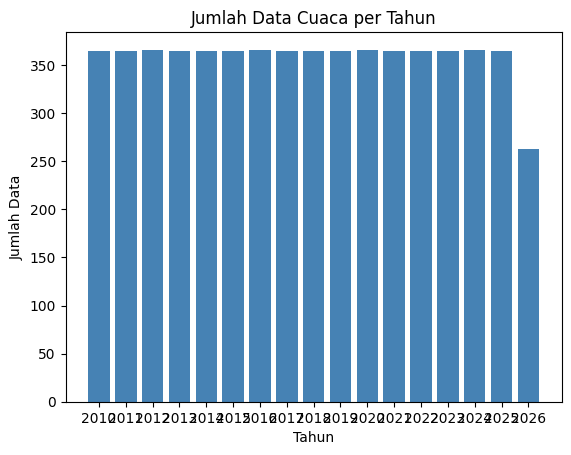

In [4]:
tahun = data_per_tahun.index.astype(str)
jumlah_data = data_per_tahun.values

plt.bar(tahun, jumlah_data, color="steelblue")

plt.title("Jumlah Data Cuaca per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Data")
plt.show()

## Analisis Velocity

Dataset cuaca ini memiliki velocity harian karena data dikumpulkan satu kali untuk setiap tanggal. Rata-rata interval antar data dapat digunakan untuk mengetahui konsistensi pengumpulan data. Jika intervalnya mendekati 1 hari, berarti data dikumpulkan secara rutin setiap hari. Jika terdapat interval lebih dari 1 hari, berarti terdapat tanggal yang tidak memiliki data.

Rata-rata interval data: 1.00 hari
Interval data yang paling sering: 1 hari
Interval minimum: 1 hari
Interval maksimum: 1 hari
Jumlah tanggal tanpa data: 0


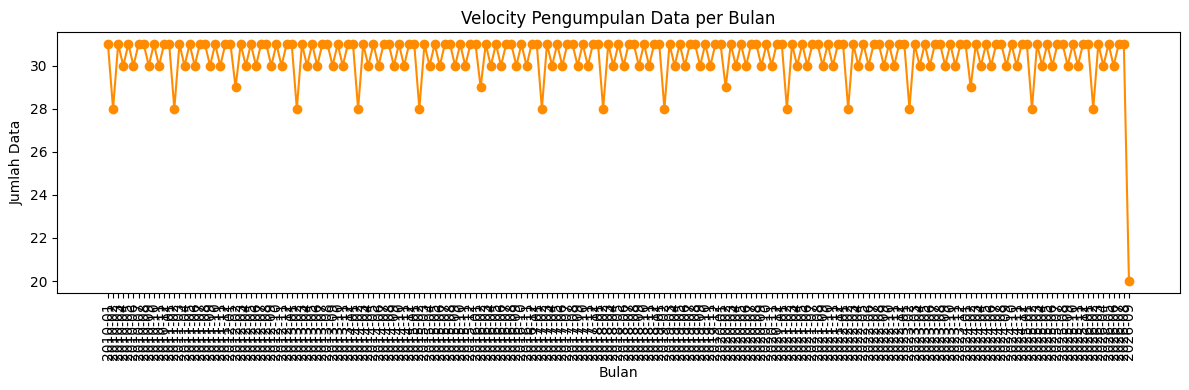

In [5]:
df["tanggal"] = pd.to_datetime(df["tanggal"])
tanggal_urut = df["tanggal"].drop_duplicates().sort_values()

selisih_hari = tanggal_urut.diff().dt.days.dropna()

print(f"Rata-rata interval data: {selisih_hari.mean():.2f} hari")
print(f"Interval data yang paling sering: {int(selisih_hari.mode().iloc[0])} hari")
print(f"Interval minimum: {int(selisih_hari.min())} hari")
print(f"Interval maksimum: {int(selisih_hari.max())} hari")

rentang_tanggal = pd.date_range(
    start=tanggal_urut.min(),
    end=tanggal_urut.max(),
    freq="D"
)
tanggal_hilang = rentang_tanggal.difference(tanggal_urut)

print(f"Jumlah tanggal tanpa data: {len(tanggal_hilang)}")

data_per_bulan = df.groupby(df["tanggal"].dt.to_period("M")).size()

plt.figure(figsize=(12, 4))
plt.plot(
    data_per_bulan.index.astype(str),
    data_per_bulan.values,
    marker="o",
    color="darkorange"
)
plt.title("Velocity Pengumpulan Data per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Interpretasi Grafik Velocity

Grafik naik turun menunjukkan jumlah data yang tercatat pada setiap bulan. Perubahan tersebut terjadi karena jumlah hari dalam setiap bulan berbeda: ada bulan yang memiliki 28, 29, 30, atau 31 hari. September 2026 juga memiliki jumlah data lebih sedikit karena pengamatan hanya berlangsung sampai tanggal 20.

Perubahan tinggi grafik tidak menunjukkan bahwa kecepatan pengambilan data berubah-ubah. Berdasarkan interval rata-rata 1 hari, interval minimum 1 hari, interval maksimum 1 hari, dan tidak adanya tanggal yang hilang, data dikumpulkan secara konsisten setiap hari. Dengan demikian, velocity dataset ini adalah harian dan stabil.

## Analisis Variety

Dataset cuaca ini merupakan dataset terstruktur karena data yang disajikan dalam bentuk tabel yang terdiri dari baris dan kolom. Dataset ini memiliki 6.107 data dengan 12 atribut. Setiap baris mempresentasikan data cuaca harian di Kabupaten Lamongan, sedangkan setiap kolom berisi informasi mengenai tanggal, kondisi cuaca, suhu, kelembapan, curah hujan, durasi hujan, kecepatan angin, hembusan angin, dan radiasi matahari.  

Dataset memiliki beberapa jenis atribut, yaitu data tanggal, kategorikal, integer, dan numerik. Atribut tangga berisi informasi tanggal pengamatan. Atribut cuaca merupakan data kategorikal yang menunjukkan kondisi cuaca. Atribut kode_cuaca merupakan data integer yang digunakan sebagai kode kondisi cuaca. Atribut suhu_maks (°C), suhu_min (°C),suhu_rata (°C), kelembapan_rata (%), curah_hujan (mm), durasi_hujan (jam), kecepatan_angin_maks (km/jam), hembusan_angin_maks (km/jam), dan radiasi_matahari (MJ/m²) termasuk dalam data numerik. 

Keragaman jenis atribut menunjukkan adanya variety dalam dataset, meskipun seluruh data masih berada dalam bentuk tabular. 

In [6]:
print("Jumlah data :", df.shape[0])
print("Jumlah atribut :", df.shape[1])

print("\nTipe data setiap atribut:")
for kolom in df.columns:
    print(kolom, ":", df[kolom].dtype)

Jumlah data : 6107
Jumlah atribut : 12

Tipe data setiap atribut:
tanggal : datetime64[ns]
kode_cuaca : int64
cuaca : object
suhu_maks (°C) : float64
suhu_min (°C) : float64
suhu_rata (°C) : float64
kelembapan_rata (%) : float64
curah_hujan (mm) : float64
durasi_hujan (jam) : float64
kecepatan_angin_maks (km/jam) : float64
hembusan_angin_maks (km/jam) : float64
radiasi_matahari (MJ/m²) : float64


## ANAlISIS VERACITY

Dataset cuaca Kabupaten Lamongan perlu dianalisis dari sisi veracity untuk mengetahui tingkat keakuratan, kelengkapan, dan konsistensi data yang digunakan. Dataset ini terdiri dari 6.107 data dengan 12 atribut yang berisi informasi mengenai kondisi cuaca harian di Kabupaten Lamongan. Setiap data memiliki informasi tanggal, kondisi cuaca, suhu, kelembapan, curah hujan, durasi hujan, kecepatan angin, hembusan angin, dan radiasi matahari.

Dari sisi kelengkapan, setiap atribut perlu diperiksa untuk mengetahui apakah terdapat data yang kosong atau missing value. Data yang tidak lengkap dapat memengaruhi hasil analisis, terutama pada atribut numerik seperti suhu, kelembapan, curah hujan, dan kecepatan angin. Selain itu, pemeriksaan juga dilakukan terhadap kemungkinan adanya data yang tidak wajar atau outlier, seperti nilai suhu, curah hujan, atau kecepatan angin yang berada jauh di luar kondisi normal.

Konsistensi data juga perlu diperhatikan dengan memastikan bahwa setiap nilai memiliki satuan dan format yang sesuai. Contohnya, atribut tanggal harus menggunakan format yang konsisten, sedangkan atribut numerik seperti suhu, curah hujan, dan kecepatan angin harus memiliki nilai yang sesuai dengan satuan yang telah ditentukan. Atribut cuaca dan kode_cuaca juga perlu diperiksa agar kode yang digunakan sesuai dengan kondisi cuaca yang direpresentasikan.

Dengan demikian, analisis veracity pada dataset cuaca Lamongan dilakukan dengan memeriksa kelengkapan, keakuratan, kewajaran, dan konsistensi data. Semakin sedikit data yang kosong, tidak wajar, atau tidak konsisten, maka semakin tinggi tingkat veracity dataset tersebut dan semakin dapat dipercaya untuk digunakan dalam analisis cuaca.

In [9]:
print("=== Analisis Veracity ===")

print("\n1. Jumlah data kosong:")
print(df.isnull().sum())

print("\n2. Jumlah data duplikat:")
print(df.duplicated().sum())

print("\n3. Statistik atribut numerik:")
print(df.describe())

print("\n4. Nilai minimum dan maksimum:")
kolom_numerik = [
    "suhu_maks (°C)",
    "suhu_min (°C)",
    "suhu_rata (°C)",
    "kelembapan_rata (%)",
    "curah_hujan (mm)",
    "durasi_hujan (jam)",
    "kecepatan_angin_maks (km/jam)",
    "hembusan_angin_maks (km/jam)",
    "radiasi_matahari (MJ/m²)"
]

for kolom in kolom_numerik:
    print(
        kolom,
        "-> Min:", df[kolom].min(),
        "| Max:", df[kolom].max()
    )

=== Analisis Veracity ===

1. Jumlah data kosong:
tanggal                          0
kode_cuaca                       0
cuaca                            0
suhu_maks (°C)                   0
suhu_min (°C)                    0
suhu_rata (°C)                   0
kelembapan_rata (%)              0
curah_hujan (mm)                 0
durasi_hujan (jam)               0
kecepatan_angin_maks (km/jam)    0
hembusan_angin_maks (km/jam)     0
radiasi_matahari (MJ/m²)         0
dtype: int64

2. Jumlah data duplikat:
0

3. Statistik atribut numerik:
                   tanggal   kode_cuaca  suhu_maks (°C)  suhu_min (°C)  \
count                 6107  6107.000000     6107.000000    6107.000000   
mean   2018-05-12 00:00:00    45.335517       31.487541      24.153493   
min    2010-01-01 00:00:00     0.000000       25.669500      18.950000   
25%    2014-03-07 12:00:00    51.000000       30.150000      23.700000   
50%    2018-05-12 00:00:00    53.000000       31.250000      24.250000   
75%    2022-07